<a href="https://colab.research.google.com/github/OnwutaKelvin/ML-notebooks/blob/main/FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.__version__)

2.10.0+cu128


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

Download FashionMNIST

In [ ]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 169kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.22MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.8MB/s]


Create Dataloaders

In [ ]:
batch_size = 64

train_dataloader = DataLoader(
    training_data,
    batch_size=batch_size
)
test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size
)

Inspecting the Data

In [ ]:
for X, y in train_dataloader:
  print("Shape of X:", X.shape)
  print("Shape of y:", y.shape)
  break

Shape of X: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64])


Image Visualization

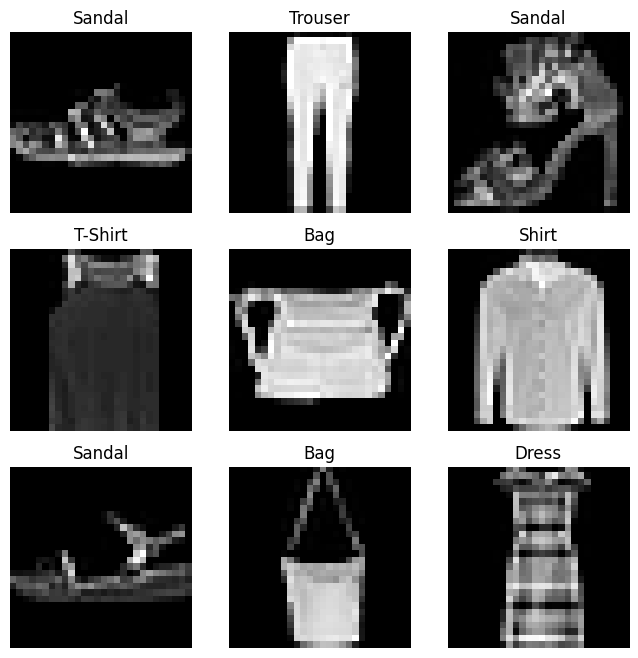

In [ ]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))

cols, rows = 3, 3

for i in range(1, cols * rows + 1):
  sample_idx = torch.randint(len(training_data), size=(1,)).item()

  img, label = training_data[sample_idx]

  figure.add_subplot(rows, cols, i)

  plt.title(labels_map[label])
  plt.axis("off")
  plt.imshow(img.squeeze(), cmap="gray")

plt.show()



Set Up Device

In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: cuda


Build the Neural Network

In [ ]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()

    self.flatten = nn.Flatten()

    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28 * 28, 512),
        nn.ReLU(),

        nn.Linear(512, 512),
        nn.ReLU(),

        nn.Linear(512, 10)
    )

  def forward(self, x):

    x = self.flatten(x)
    logits = self.linear_relu_stack(x)

    return logits

In [ ]:
model = NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Defining loss function and optimizer

In [ ]:
#loss function
loss_fn = nn.CrossEntropyLoss()

In [ ]:
#optimizer
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=1e-3
)

Training Loop

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)

  model.train()

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)

    #forward pass
    pred = model(X)

    loss = loss_fn(pred, y)

    #backpropagation
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if batch % 100 == 0:
      loss_value = loss.item()

      current = batch * len(X)

      print(
          f"Loss: {loss_value:>7f} "
          f"[{current:>5d}/{size:>5d}]"
      )

Test Loop

In [ ]:
def test(dataloader, model, loss_fn):

  size = len(dataloader.dataset)

  num_batches = len(dataloader)

  model.eval()

  test_loss = 0
  correct = 0

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)

      pred = model(X)

      test_loss += loss_fn(pred, y).item()

      correct += (
          (pred.argmax(1) == y)
          .type(torch.float)
          .sum()
          .item()
      )

  test_loss /= num_batches
  correct /= size

  print(
      f"Test Error: \n"
      f"Accuracy: {(100*correct):>0.1f}% \n"
      f"Avg Loss: {test_loss:>8f}\n"
  )



Train the model

In [ ]:
epochs = 10
for t in range (epochs):
  print(f"Epoch {t+1}\n---------------")

  train(train_dataloader, model, loss_fn, optimizer)
  test(test_dataloader, model, loss_fn)

print("Done!")

Epoch 1
---------------
Loss: 2.309759 [    0/60000]
Loss: 2.296311 [ 6400/60000]
Loss: 2.274133 [12800/60000]
Loss: 2.268239 [19200/60000]
Loss: 2.251549 [25600/60000]
Loss: 2.223849 [32000/60000]
Loss: 2.236874 [38400/60000]
Loss: 2.200979 [44800/60000]
Loss: 2.193663 [51200/60000]
Loss: 2.173098 [57600/60000]
Test Error: 
Accuracy: 41.9% 
Avg Loss: 2.159389

Epoch 2
---------------
Loss: 2.172478 [    0/60000]
Loss: 2.161004 [ 6400/60000]
Loss: 2.106145 [12800/60000]
Loss: 2.120433 [19200/60000]
Loss: 2.064376 [25600/60000]
Loss: 2.016646 [32000/60000]
Loss: 2.042468 [38400/60000]
Loss: 1.969645 [44800/60000]
Loss: 1.965218 [51200/60000]
Loss: 1.907069 [57600/60000]
Test Error: 
Accuracy: 51.5% 
Avg Loss: 1.896306

Epoch 3
---------------
Loss: 1.931030 [    0/60000]
Loss: 1.900892 [ 6400/60000]
Loss: 1.786390 [12800/60000]
Loss: 1.825758 [19200/60000]
Loss: 1.708637 [25600/60000]
Loss: 1.674768 [32000/60000]
Loss: 1.688562 [38400/60000]
Loss: 1.600053 [44800/60000]
Loss: 1.611932 [

Making Predictions

In [ ]:
classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot",
]

model.eval()
x, y = test_data[0]

with torch.no_grad():
  x = x.to(device)
  pred = model(x)

  predicted = classes[pred[0].argmax(0)]

  actual = classes[y]

  print(f"Predicted: {predicted}")
  print(f"Actual: {actual}")

Predicted: Ankle Boot
Actual: Ankle Boot
